Ntrotter  0


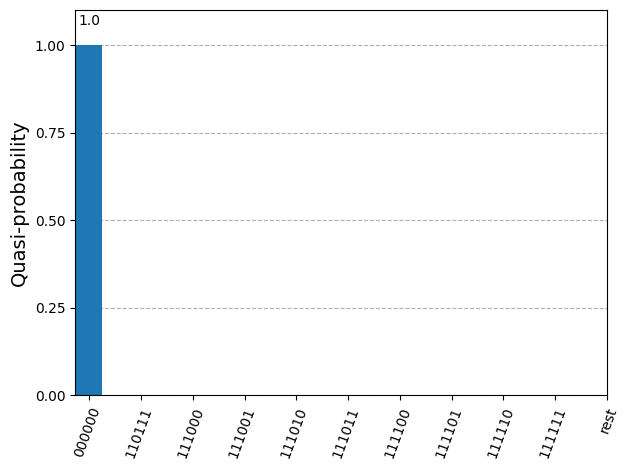

Ntrotter  1


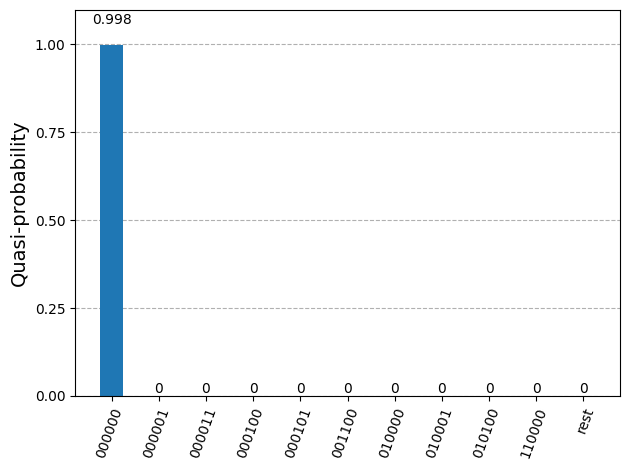

Ntrotter  2


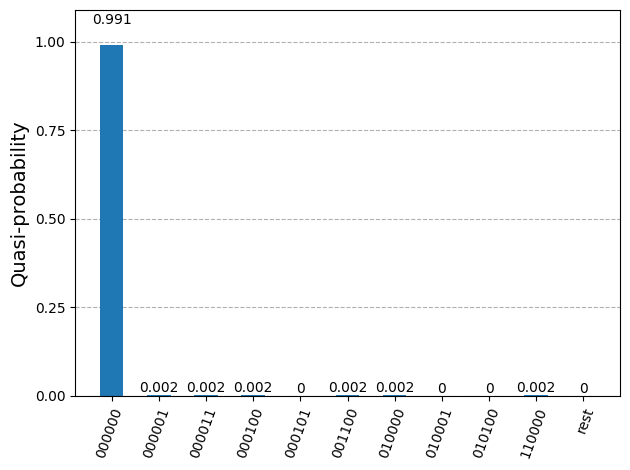

Ntrotter  3


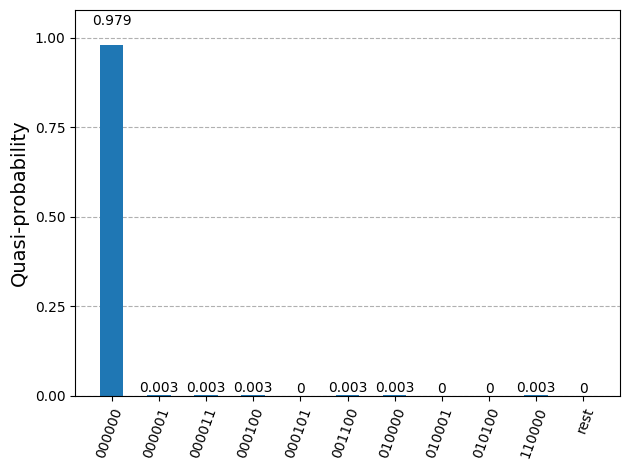

Ntrotter  4


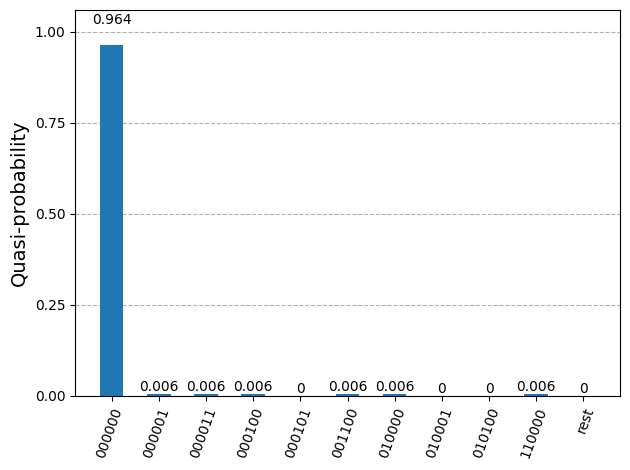

Ntrotter  5


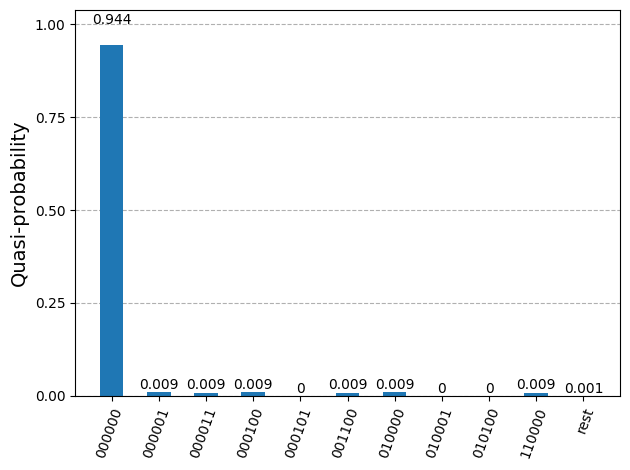

Ntrotter  6


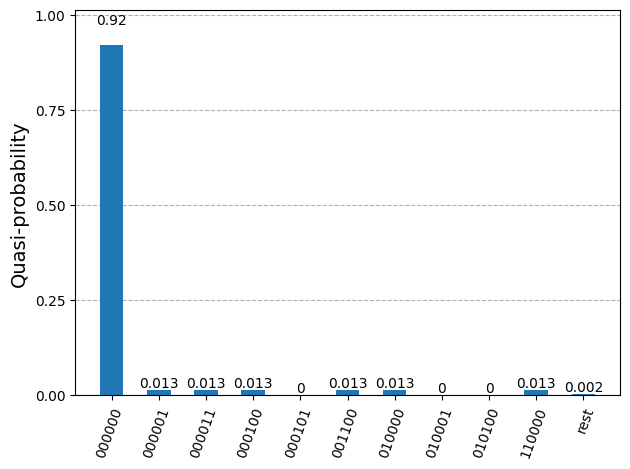

Ntrotter  7


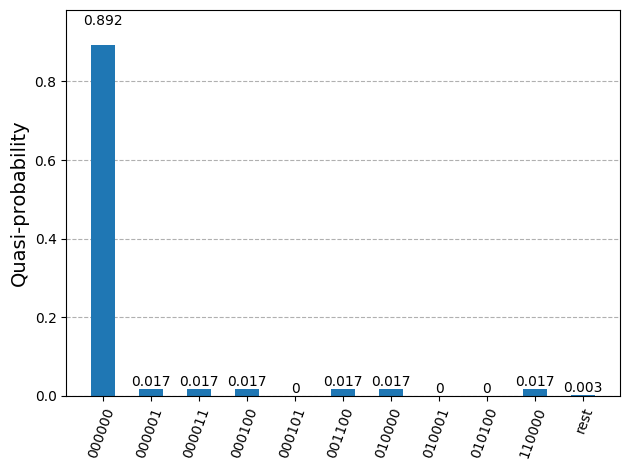

Ntrotter  8


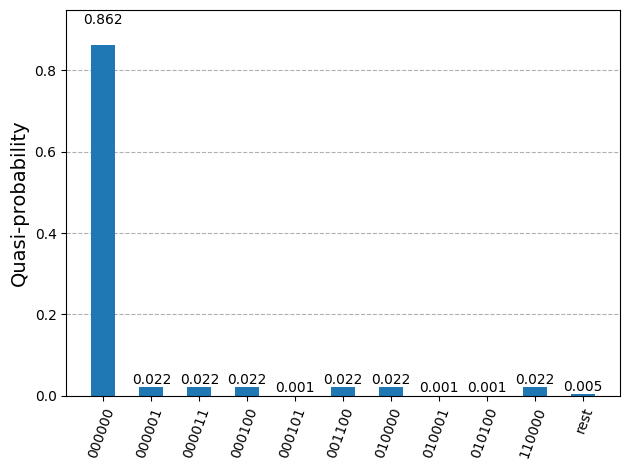

Ntrotter  9


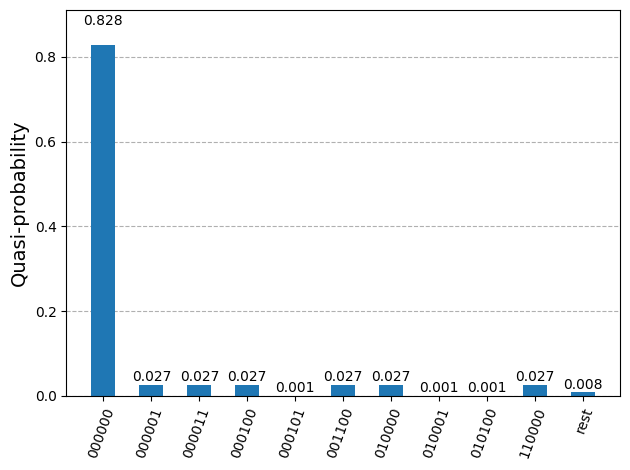

Ntrotter  10


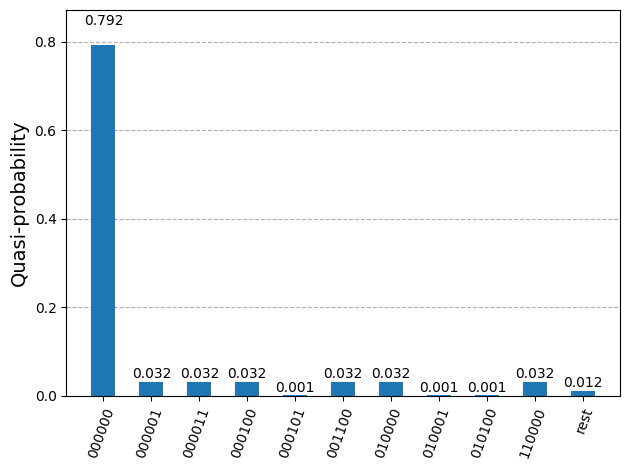

Ntrotter  11


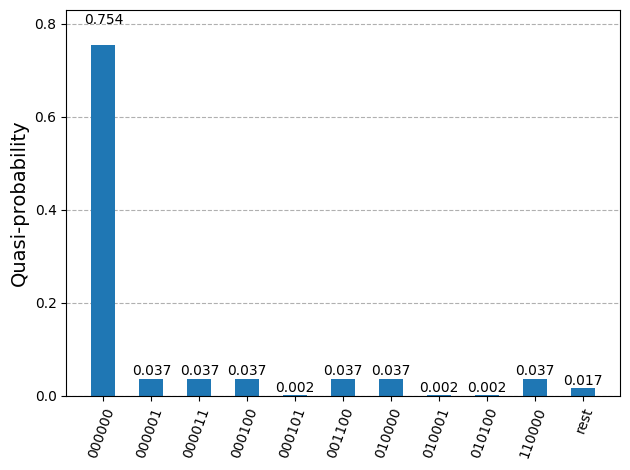

Ntrotter  12


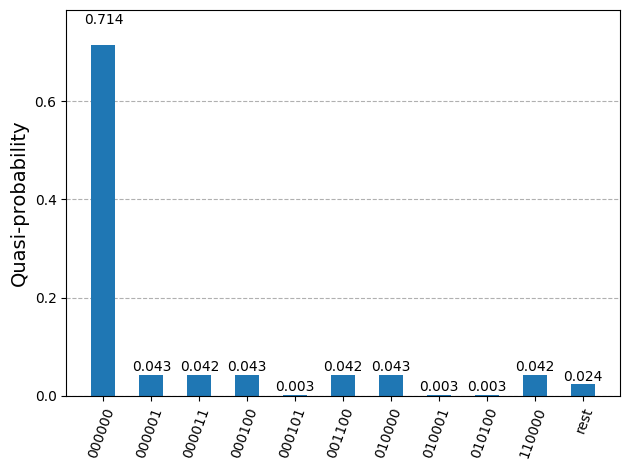

Ntrotter  13


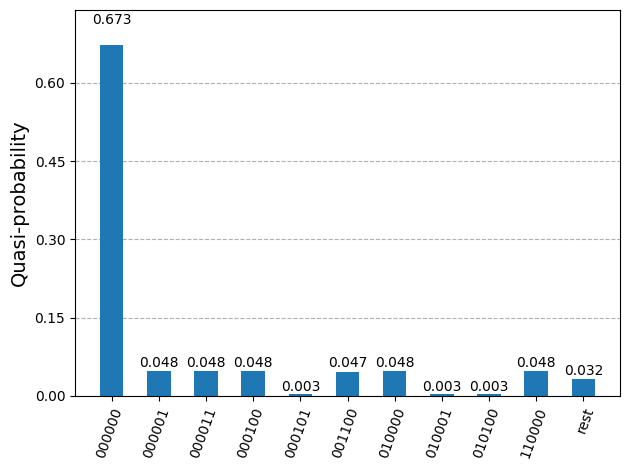

Ntrotter  14


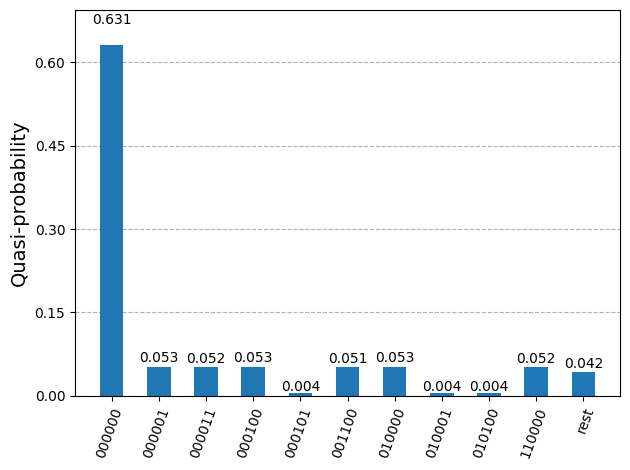

Ntrotter  15


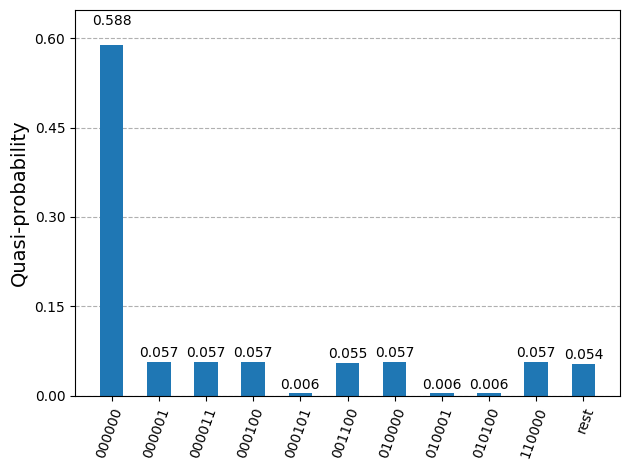

Ntrotter  16


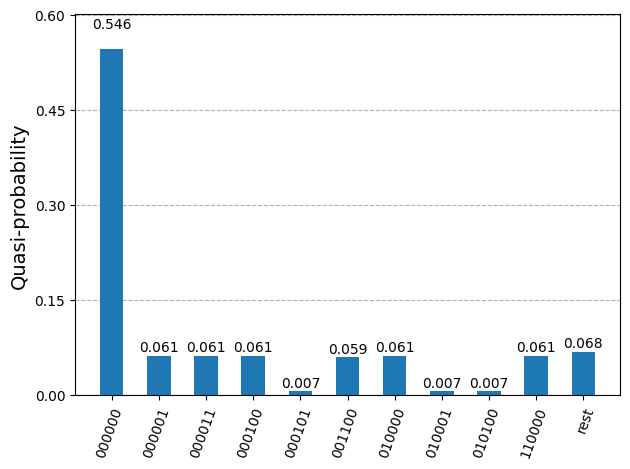

Ntrotter  17


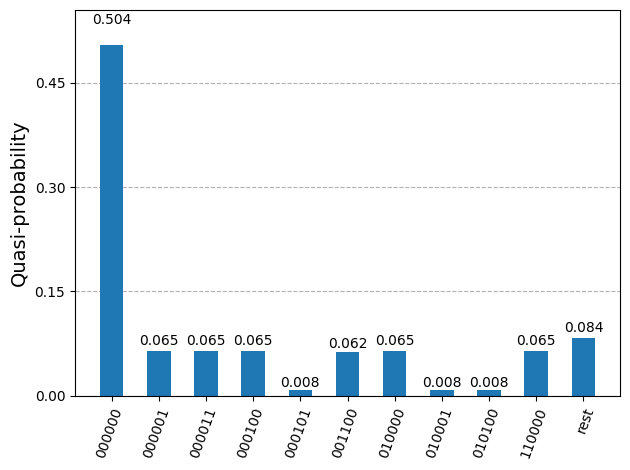

Ntrotter  18


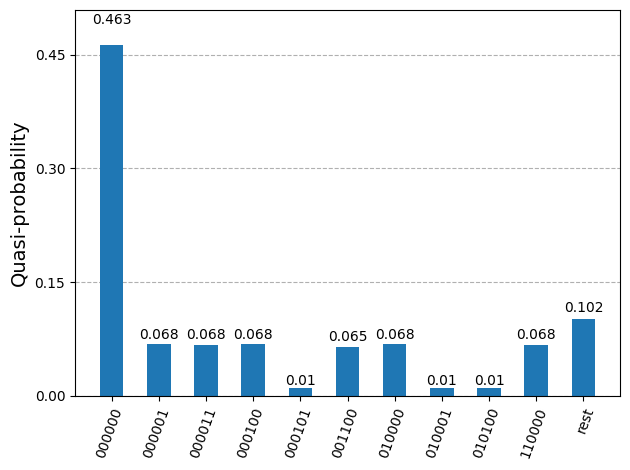

Ntrotter  19


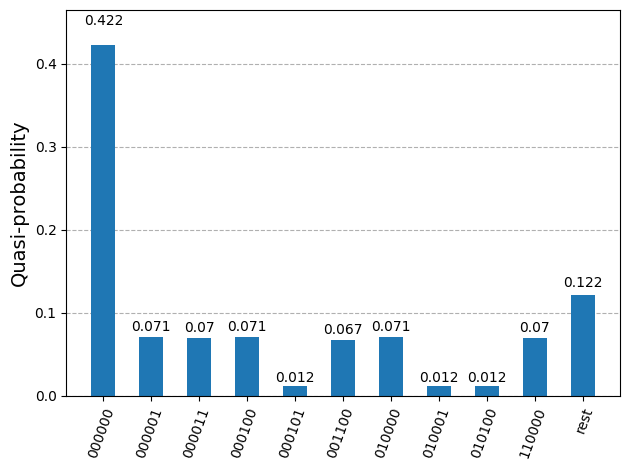

Ntrotter  20


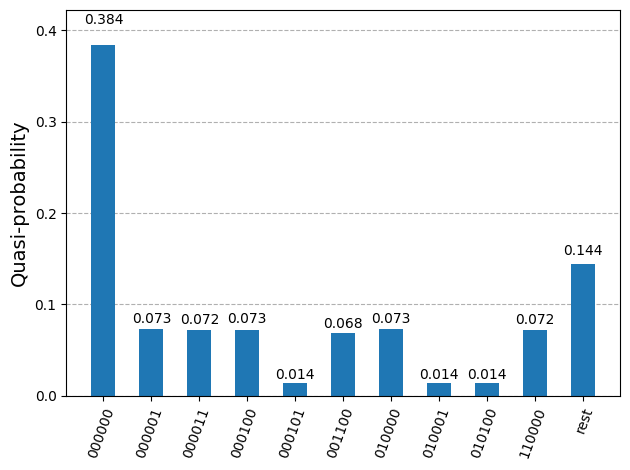

Ntrotter  21


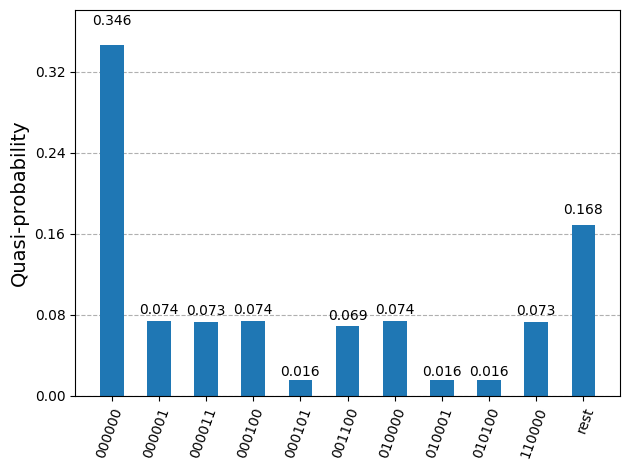

Ntrotter  22


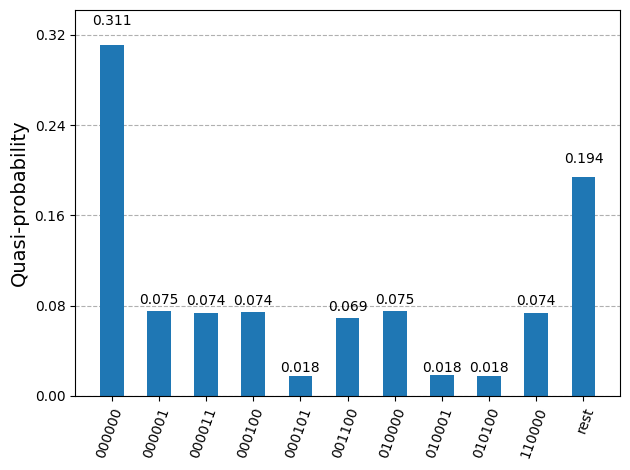

Ntrotter  23


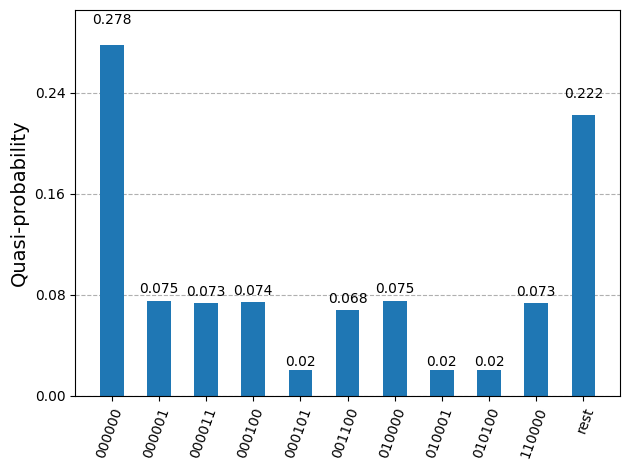

Ntrotter  24


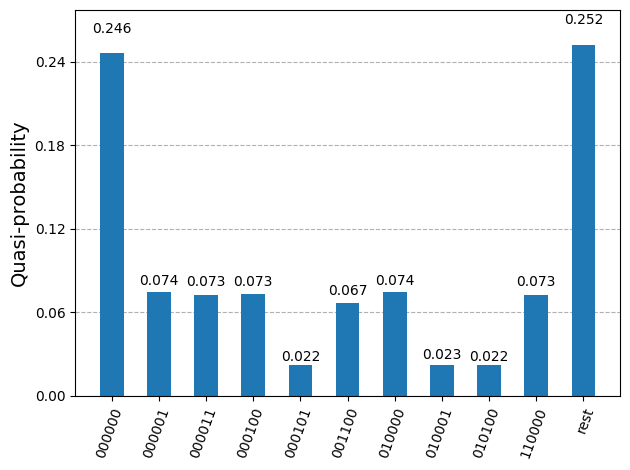

Ntrotter  25


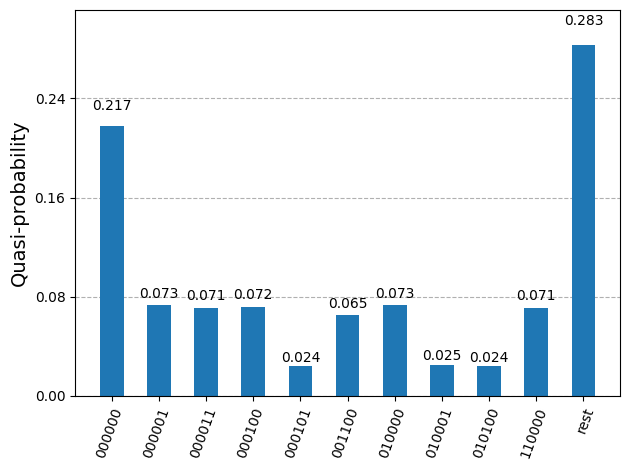

Ntrotter  26


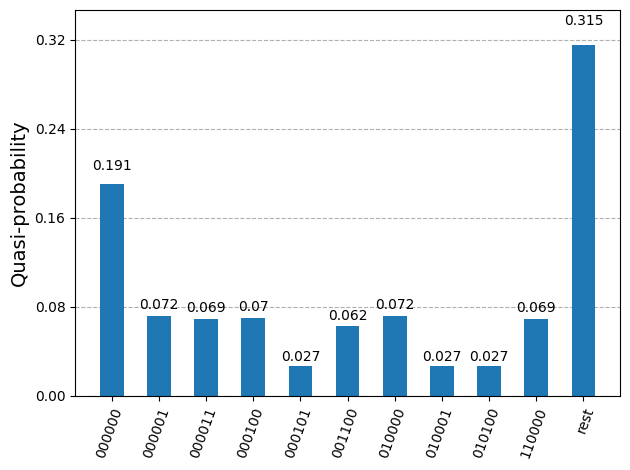

Ntrotter  27


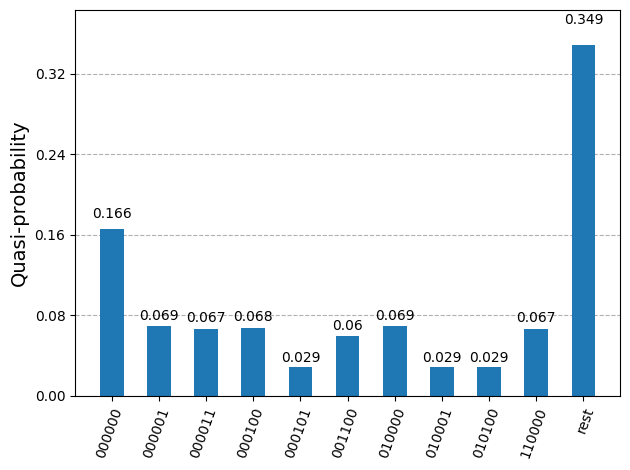

Ntrotter  28


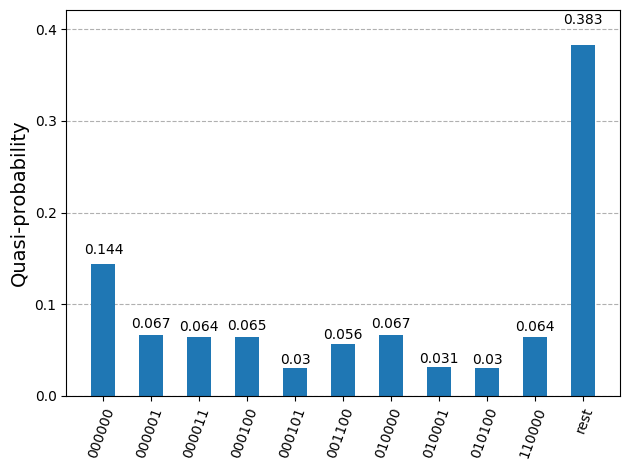

Ntrotter  29


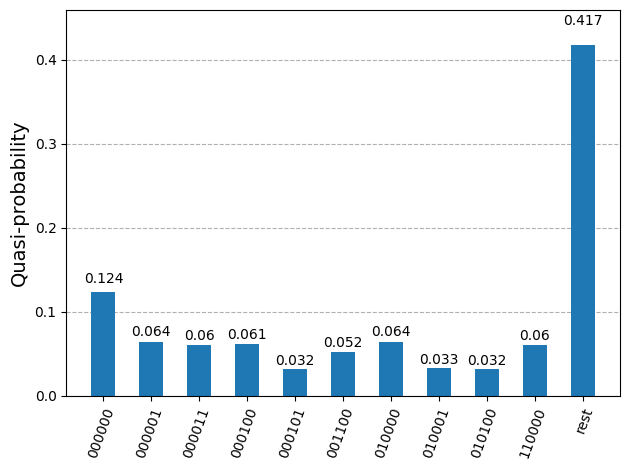

Ntrotter  30


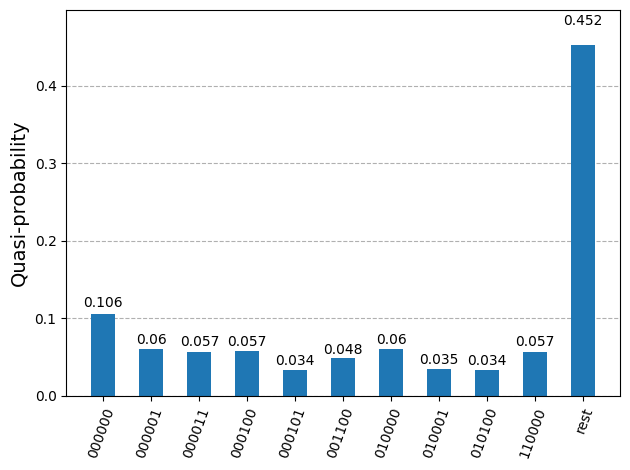

Ntrotter  31


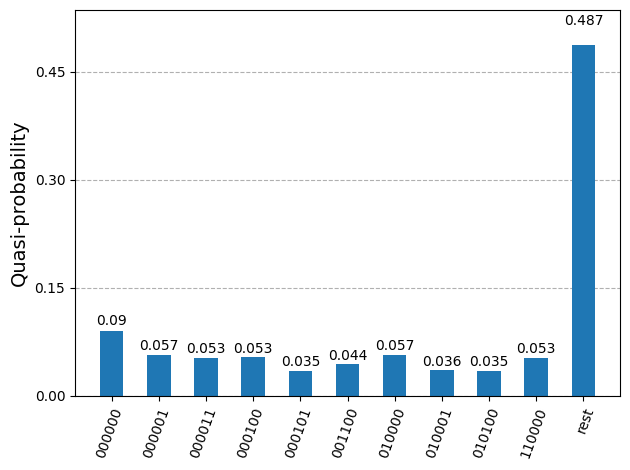

Ntrotter  32


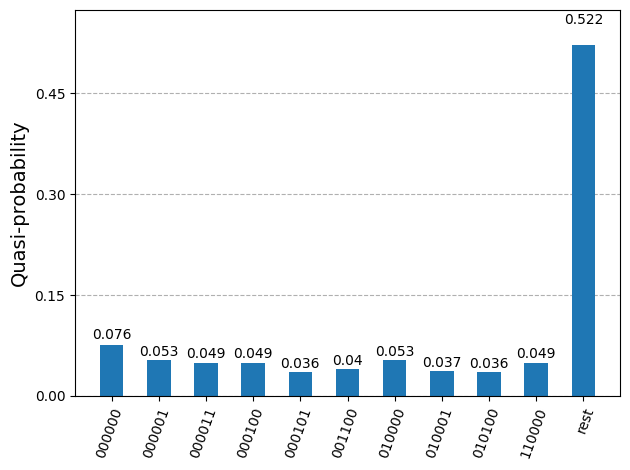

Ntrotter  33


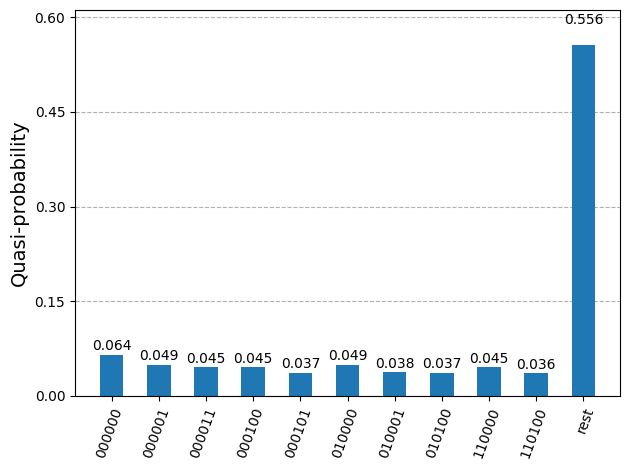

Ntrotter  34


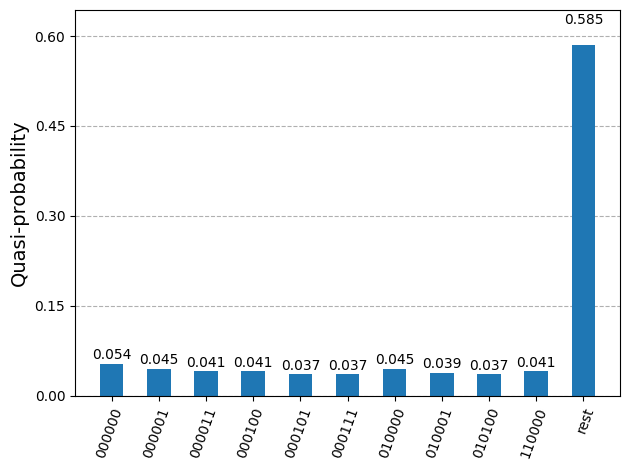

Ntrotter  35


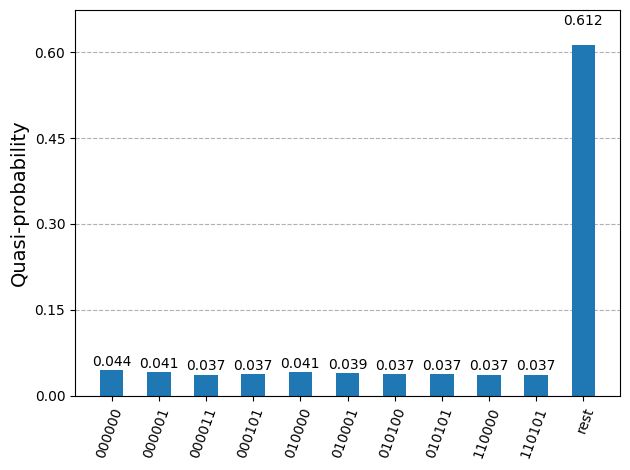

Ntrotter  36


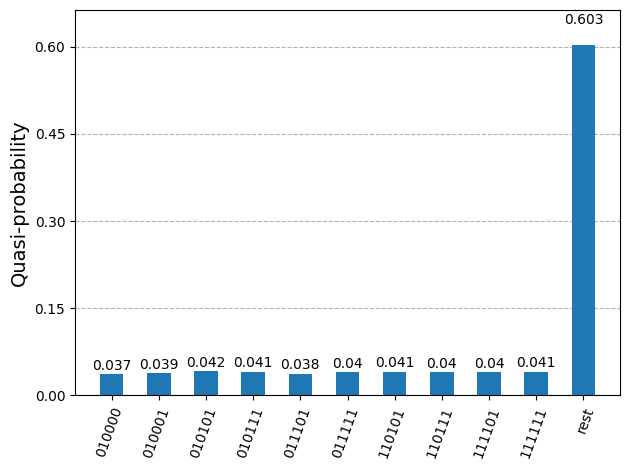

Ntrotter  37


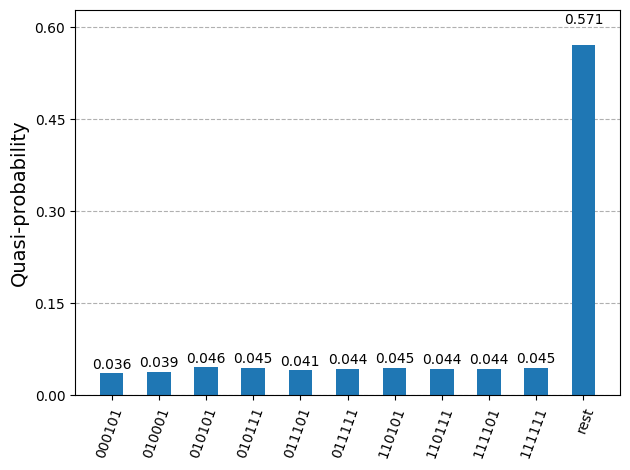

Ntrotter  38


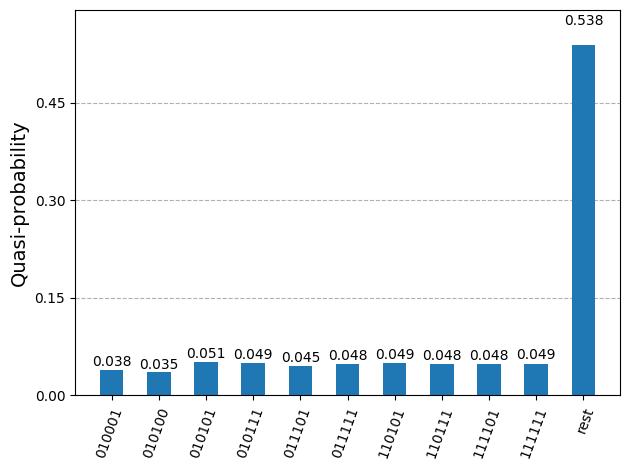

Ntrotter  39


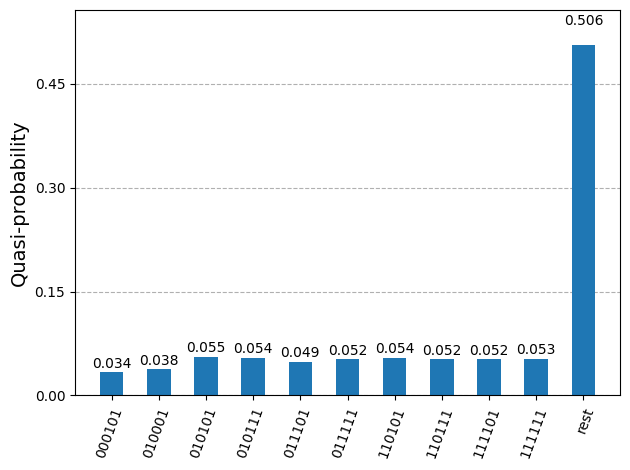

Ntrotter  40


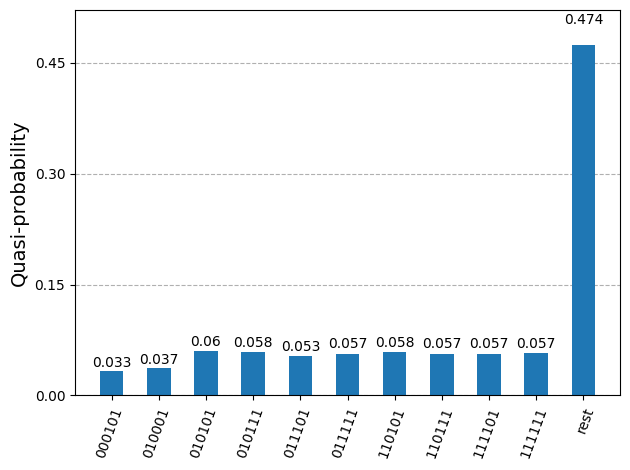

In [1]:
# H = J1 sum_{j=0}^{L-1} pi_j^2 + J2 sum_{j=0}^{L-1} phi_j^2 + J3 sum_{j=0}^{L-2} (phi_{j+1} - phi_j)^2 + J4 sum_{j=0}^{L-1} phi_j^4

import numpy as np
from functools import reduce
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

%matplotlib inline

# time evolution parameters
Ntrotter_max = 40
dt           = 0.01
t_set        = [x*dt for x in range(Ntrotter_max+1)]

# lattice parameters
L         = 3 # number of sites
nq_1site  = 2 # number of qubits representing 1 site
nq        = L*nq_1site # total number of qubits
dim       = 2**nq
phi_max   = 1
delta_phi = (2*phi_max)/(2**nq_1site -1)

# couplings 
J1, J2, J3, J4 = [1/2, 1/2, 1/2, 1]

# initial state
ini    = np.zeros((dim,1), dtype=complex)
ini[0] = 1

# Fourier transform (took it from Gaetan's code)
N    = 2**nq_1site
n    = np.arange(N)
F    = np.exp(-2j * np.pi * np.outer(n, n) / N) / np.sqrt(N)
Fdag = F.conj().T

# eigenvalues (with definitions that make more sense hopefuly)
# operators acting on the qubits: 
# phi_j = phi_max/(2**nq_1site -1) (2 Z_{2j} + Z_{2j+1}) -> eigenvalues phi_max/(2**nq_1site -1) * {3, 1, -1, -3}
# pi_j = pi/(4*delta_phi) (2 Z_{2j} + Z_{2j+1}) -> eigenvalues pi/(4*delta_phi) * {3, 1, -1, -3}
 
phi_eig   = [phi_max-x*delta_phi for x in range(2**nq_1site)]
pi_eig    = [x*np.pi/(4*delta_phi) for x in [3, 1, -1, -3]]

# basic operators acting on a single site
PHI = np.diag(phi_eig)
PI  = Fdag @ np.diag(pi_eig) @ F
ID  = np.eye(2**nq_1site)

# H1 = sum_{j=0}^{L-1} pi_j^2
H1 = np.zeros((dim,dim), dtype=complex)
for j in range(L):
    ops    = [ID]*L
    ops[j] = PI @ PI
    H1    += reduce(np.kron, ops) # applies the operation np.kron (tensor product) between elements of ops (ID x ... x PI^2 x ... x ID)

# H2 = sum_{j=0}^{L-1} phi_j^2
H2 = np.zeros((dim,dim), dtype=complex)
for j in range(L):
    ops    = [ID]*L
    ops[j] = PHI @ PHI
    H2    += reduce(np.kron, ops)

# H3 = sum_{j=0}^{L-2} phi_{j+1}^2 + phi_j^2 - 2 phi_j phi_{j+1}
H3 = np.zeros((dim,dim), dtype=complex)
for j in range(L-1):
    # phi_j^2
    ops    = [ID]*L
    ops[j] = PHI @ PHI
    H3    += reduce(np.kron, ops)

    # phi_{j+1}^2
    ops      = [ID]*L
    ops[j+1] = PHI @ PHI
    H3      += reduce(np.kron, ops)

    # - 2 phi_j phi_{j+1}
    ops      = [ID]*L
    ops[j]   = -2*PHI
    ops[j+1] = PHI
    H3      += reduce(np.kron, ops)

# H4 = sum_{j=0}^{L-1} phi_j^4
H4 = np.zeros((dim,dim), dtype=complex)
for j in range(L):
    ops    = [ID]*L
    ops[j] = PHI @ PHI @ PHI @ PHI
    H4    += reduce(np.kron, ops)

# full Hamiltonian
H = J1 * H1 + J2 * H2 + J3 * H3 + J4 * H4

# evolution
n = 0
for t in t_set:
    print('Ntrotter ', n)
    U         = expm(-1j * H * t)
    st        = U @ ini
    probs     = [np.abs(st[x][0])**2 for x in range(dim)]
    labels    = [format(i, f'0{nq}b') for i in range(len(probs))]
    prob_dict = {labels[i]: probs[i] for i in range(len(probs))}
    
    plot_histogram(prob_dict, number_to_keep=10)
    plt.show()
    
    n += 1